**Fig 2. Pro-seq signals in relationship to gene structure and strand**

A. Summaries 5’, beg, end, 3’ on both strands

B. Phases (here using the bins as we have no KF yet)

C. Show phase in function of position to motivate the KF (spirals)


In [15]:
import numpy as np
import pandas as pd
from multiprocessing import Pool
from functools import partial
import matplotlib.pyplot as plt
import pyBigWig as bw
import sys
sys.path.insert(0, '/home/jbreda/PROseq/scripts/Phase_to_LabColor')
from phase_to_labcolor import phase_to_labcolor as p2lc
sys.path.insert(0, '/home/jbreda/PROseq/scripts/FourierTransform')
from fourier_transform import fourier_transform


def get_gtf(infile):

    # Read gtf file
    gtf = pd.read_csv(infile,sep='\t',header=None)
    gtf.columns = ['chr','source','type','start','end','score','strand','frame','attribute']
    gtf['gene_name'] = gtf.attribute.str.extract(r'gene_name "(.*?)";')
    N_gene = gtf.shape[0]

    # fix gene duplicates
    dup = gtf.gene_name.value_counts()
    my_genes = dup[dup>1].index
    for g in my_genes:
        idx = gtf[gtf.gene_name==g].index
        same_chr = (gtf.loc[idx,['chr','strand']].nunique().values == 1).all()
        overlap =  gtf.loc[idx,'end'].max() - gtf.loc[idx,'start'].min() < (gtf.loc[idx,'end'].values - gtf.loc[idx,'start'].values).sum()*2
        #gtf.loc[idx,['start']].values.max() < gtf.loc[idx,['end']].values.min()
        if same_chr and overlap:

            gtf.loc[idx[0],'start'] = gtf.loc[idx,'start'].min()
            gtf.loc[idx[0],'end'] = gtf.loc[idx,'end'].max()
            gtf.drop(idx[1:],inplace=True)
            
        else:
            print(g)
            gtf.loc[idx,'gene_name'] = [f'{g}_{i}' for i in range(len(idx))]
    gtf.set_index('gene_name',inplace=True,drop=True)

    return gtf


def get_count_phase_amp_in_window(coord,genome='GRCm38'):

    # get coordinates and time points
    T = np.arange(0,48,4)
    strand_dict = {'+': 'forward', '-': 'reverse'}
    [chr,start,end,strand] = coord.split(':')
    start = int(start)
    end = int(end)

    X = np.zeros((1,len(T)))
    bw_folder = f'../results/{genome}/norm_coverage'
    for j,t in enumerate(T):

        sample = f'CT{t:02d}'
        fin = bw.open(f"{bw_folder}/{sample}/NormCoverage_3p_{strand_dict[strand]}.bw")
        vals = fin.intervals(chr,start,end)
        # get summed count for each time point
        if not vals is None:
            X[0,j] = sum([vals[i][2] for i in range(len(vals))])
    
    # get mean expression per bp
    count_per_bp = X.sum(axis=1)/(end-start)

    # log transform, add pseudo counts and average gene expression across bins
    X = np.log2(X + 1)

    # Get amp phase: fourier transform
    τ = 24 # period [h]
    ω = 2*np.pi/τ
    phi_n, a_n, R2, pval, mu_n = fourier_transform(X,T,ω)

    return X, count_per_bp, phi_n, a_n, R2, pval, mu_n

def get_expression_in_window(coord, bin_size,genome='GRCm38',fill_empty_bin=True):

    T = np.arange(0,48,4)
    strand_dict = {'+': 'forward', '-': 'reverse'}
    [chr,start,end,strand] = coord.split(':')
    start = int(start)
    end = int(end)

    # Load bigWigs to dataframe
    df = pd.DataFrame(columns=['start','end'])
    bw_folder = f'../results/{genome}/binned_norm_coverage'
    for t in T:
        sample = f'CT{t:02d}'
        fin = f"{bw_folder}/{sample}/NormCoverage_3p_{strand_dict[strand]}_bin{bin_size}bp.bw"
        with bw.open(fin,'r') as bw_file:
            df_t = pd.DataFrame(bw_file.intervals(chr,start,end),columns=['start','end',f"{t}"])
        df = pd.merge(df,df_t,on=['start','end'],how='outer')
    df.sort_values('start',inplace=True)
    df.reset_index(inplace=True,drop=True)

    # replace start and end with position in the middle of the bin, and set as index
    df['start'] = ( df.start.values + bin_size/2 ).astype(int) # bp
    df.rename(columns={'start':'pos'},inplace=True)
    df.drop('end',axis=1,inplace=True)
    df.set_index('pos',inplace=True)
    df.fillna(0,inplace=True)
    df = df.apply(lambda x: np.log2(x+1),axis=1)

    # fill empty bins with 0
    if fill_empty_bin:
        start_bin = start//bin_size*bin_size + int(bin_size/2)
        end_bin = int(np.ceil(end/bin_size)*bin_size) - int(bin_size/2)
        x = np.arange(start_bin, end_bin+1, bin_size)
        positions = df.index.values
        missing_pos = np.setdiff1d(x,positions)
        if len(missing_pos) > 0:
            missing = pd.DataFrame(np.ones((missing_pos.shape[0],df.shape[1])),index=missing_pos,columns=df.columns)
            df = pd.concat([df,missing],axis=0)
            df.sort_index(inplace=True)
        

    return df

def get_flank_expression_phase(genome,bin_size,n_bins_flank,coord):
    ω = 2*np.pi/24
    T = np.arange(0,48,4)
    N = T.shape[0]

    # get gene coordinates
    chr, start, end, strand = coord
    
    # get the opposite strand ( - if strand is + and + if strand is -)
    strand_opp = '+-'.replace(strand,'')

    # get gene mean expression
    X = get_expression_in_window(f'{chr}:{start}:{end}:{strand}', bin_size, genome,fill_empty_bin=True)
    μ = X.values.mean()

    # get gene phase, amplitude and mean expression
    #with h5py.File(infile_kalman_on_genes, 'r') as hf:
    #    μ_tT = hf[gene]['mu'][:].T
    #μ_tT = μ_tT[0,:] + 1j*μ_tT[1,:]
    #φ_start = -np.arctan2(np.imag(μ_tT[0]),np.real(μ_tT[0]))
    #if φ_start<0:
    #    φ_start += 2*np.pi # make sure φ_n is between 0 and 2pi
    #φ_end = -np.arctan2(np.imag(μ_tT[-1]),np.real(μ_tT[-1]))
    #if φ_end<0:
    #    φ_end += 2*np.pi # make sure φ_n is between 0 and 2pi

    coord_start = f'{chr}:{start}:{start+2000}:{strand}'
    X_start, count_per_bp_start, φ_start, a_start, R2_start, pval_start, mu_start = get_count_phase_amp_in_window(coord_start,genome)
    coord_end = f'{chr}:{end-2000}:{end}:{strand}'
    X_end, count_per_bp_end, φ_end, a_end, R2_end, pval_end, mu_end = get_count_phase_amp_in_window(coord_end,genome)


    flank_size = n_bins_flank*bin_size
    Flanks = {}
    Flanks['same_up']    = get_expression_in_window(f'{chr}:{start-flank_size}:{start}:{strand}', bin_size, genome,fill_empty_bin=True)
    Flanks['same_start'] = get_expression_in_window(f'{chr}:{start}:{start+flank_size}:{strand}', bin_size, genome,fill_empty_bin=True)
    Flanks['same_end']   = get_expression_in_window(f'{chr}:{end-flank_size}:{end}:{strand}', bin_size, genome,fill_empty_bin=True)
    Flanks['same_down']  = get_expression_in_window(f'{chr}:{end}:{end+flank_size+1}:{strand}', bin_size, genome,fill_empty_bin=True)
    Flanks['opp_up'] =    get_expression_in_window(f'{chr}:{start-flank_size}:{start}:{strand_opp}', bin_size, genome,fill_empty_bin=True)
    Flanks['opp_start'] = get_expression_in_window(f'{chr}:{start}:{start+flank_size}:{strand_opp}', bin_size, genome,fill_empty_bin=True)
    Flanks['opp_end'] =   get_expression_in_window(f'{chr}:{end-flank_size}:{end}:{strand_opp}', bin_size, genome,fill_empty_bin=True)
    Flanks['opp_down'] =  get_expression_in_window(f'{chr}:{end}:{end+flank_size}:{strand_opp}', bin_size, genome,fill_empty_bin=True)

    # make sure that the retrieved matrix have n_bins_flank+1 bins
    for flank in Flanks:
        if Flanks[flank].shape[0] != n_bins_flank:
            if flank.split('_')[1] in ['up','start']:
                Flanks[flank] = Flanks[flank].iloc[1:,:]
            if flank.split('_')[1] in ['end','down']:
                Flanks[flank] = Flanks[flank].iloc[:-1,:]
    
    if strand == '-':
        # flip flanks
        Flanks['same_up'], Flanks['same_start'], Flanks['same_end'],  Flanks['same_down'] = Flanks['same_down'], Flanks['same_end'], Flanks['same_start'], Flanks['same_up']
        Flanks['opp_up'], Flanks['opp_start'], Flanks['opp_end'],  Flanks['opp_down'] = Flanks['opp_down'], Flanks['opp_end'], Flanks['opp_start'], Flanks['opp_up']
    
        # invert index order
        for flank in Flanks:
            Flanks[flank].sort_index(inplace=True,ascending=False)

    # get flanks phase
    f_flanks = {}
    φ_flanks = {}
    μ_flanks = {}
    for flank in Flanks:
        if flank in ['same_up','opp_up','same_start','opp_start']:
            φ = φ_start
        elif flank in ['same_down','opp_down','same_end','opp_end']:
            φ = φ_end
            
        idx_out = Flanks[flank].var(1) < 1e-10

        f_flanks[flank] = np.sum( Flanks[flank].values * np.exp(-1j*ω*T) ,1)
        f_flanks[flank][idx_out] = np.nan
        
        φ_flanks[flank] = -np.arctan2(np.imag(f_flanks[flank]),np.real(f_flanks[flank]))
        φ_flanks[flank][φ_flanks[flank]<0] += 2*np.pi
        # relative to gene phase
        φ_flanks[flank] = φ_flanks[flank] - φ
        φ_flanks[flank] = (φ_flanks[flank] + np.pi) % (2*np.pi) - np.pi
        φ_flanks[flank][idx_out] = np.nan

        μ_flanks[flank] = (Flanks[flank].values.mean(1) - μ)/np.log(2)

    
    return μ_flanks, φ_flanks


def get_flank_expression_phase_amp_r2(genome,bin_size,n_bins_flank,coord):
    ω = 2*np.pi/24
    T = np.arange(0,48,4)
    N = T.shape[0]

    # get gene coordinates
    chr, start, end, strand = coord
    
    # get the opposite strand ( - if strand is + and + if strand is -)
    strand_opp = '+-'.replace(strand,'')

    # get gene mean expression
    X = get_expression_in_window(f'{chr}:{start}:{end}:{strand}', bin_size, genome,fill_empty_bin=True)
    μ = X.values.mean()

    # get gene phase, amplitude and mean expression
    #with h5py.File(infile_kalman_on_genes, 'r') as hf:
    #    μ_tT = hf[gene]['mu'][:].T
    #μ_tT = μ_tT[0,:] + 1j*μ_tT[1,:]
    #φ_start = -np.arctan2(np.imag(μ_tT[0]),np.real(μ_tT[0]))
    #if φ_start<0:
    #    φ_start += 2*np.pi # make sure φ_n is between 0 and 2pi
    #φ_end = -np.arctan2(np.imag(μ_tT[-1]),np.real(μ_tT[-1]))
    #if φ_end<0:
    #    φ_end += 2*np.pi # make sure φ_n is between 0 and 2pi

    coord_start = f'{chr}:{start}:{start+2000}:{strand}'
    X_start, count_per_bp_start, φ_start, a_start, R2_start, pval_start, mu_start = get_count_phase_amp_in_window(coord_start,genome)
    coord_end = f'{chr}:{end-2000}:{end}:{strand}'
    X_end, count_per_bp_end, φ_end, a_end, R2_end, pval_end, mu_end = get_count_phase_amp_in_window(coord_end,genome)


    flank_size = n_bins_flank*bin_size
    Flanks = {}
    Flanks['same_up']    = get_expression_in_window(f'{chr}:{start-flank_size}:{start}:{strand}', bin_size, genome,fill_empty_bin=True)
    Flanks['same_start'] = get_expression_in_window(f'{chr}:{start}:{start+flank_size}:{strand}', bin_size, genome,fill_empty_bin=True)
    Flanks['same_end']   = get_expression_in_window(f'{chr}:{end-flank_size}:{end}:{strand}', bin_size, genome,fill_empty_bin=True)
    Flanks['same_down']  = get_expression_in_window(f'{chr}:{end}:{end+flank_size+1}:{strand}', bin_size, genome,fill_empty_bin=True)
    Flanks['opp_up'] =    get_expression_in_window(f'{chr}:{start-flank_size}:{start}:{strand_opp}', bin_size, genome,fill_empty_bin=True)
    Flanks['opp_start'] = get_expression_in_window(f'{chr}:{start}:{start+flank_size}:{strand_opp}', bin_size, genome,fill_empty_bin=True)
    Flanks['opp_end'] =   get_expression_in_window(f'{chr}:{end-flank_size}:{end}:{strand_opp}', bin_size, genome,fill_empty_bin=True)
    Flanks['opp_down'] =  get_expression_in_window(f'{chr}:{end}:{end+flank_size}:{strand_opp}', bin_size, genome,fill_empty_bin=True)

    # make sure that the retrieved matrix have n_bins_flank+1 bins
    for flank in Flanks:
        if Flanks[flank].shape[0] != n_bins_flank:
            if flank.split('_')[1] in ['up','start']:
                Flanks[flank] = Flanks[flank].iloc[1:,:]
            if flank.split('_')[1] in ['end','down']:
                Flanks[flank] = Flanks[flank].iloc[:-1,:]
    
    if strand == '-':
        # flip flanks
        Flanks['same_up'], Flanks['same_start'], Flanks['same_end'],  Flanks['same_down'] = Flanks['same_down'], Flanks['same_end'], Flanks['same_start'], Flanks['same_up']
        Flanks['opp_up'], Flanks['opp_start'], Flanks['opp_end'],  Flanks['opp_down'] = Flanks['opp_down'], Flanks['opp_end'], Flanks['opp_start'], Flanks['opp_up']
    
        # invert index order
        for flank in Flanks:
            Flanks[flank].sort_index(inplace=True,ascending=False)

    # get flanks phase
    f_flanks = {}
    φ_flanks = {}
    μ_flanks = {}
    A_flanks = {}
    R2_flanks = {}
    for flank in Flanks:
        if flank in ['same_up','opp_up','same_start','opp_start']:
            φ = φ_start
        elif flank in ['same_down','opp_down','same_end','opp_end']:
            φ = φ_end
            
        idx_out = Flanks[flank].var(1) < 1e-10

        φ_f, a_f, R2_f, pval_f, μ_f = fourier_transform(Flanks[flank].values,T,ω)
        
        A_flanks[flank] = a_f

        # relative to gene phase
        φ_flanks[flank] = φ_f - φ
        φ_flanks[flank] = (φ_flanks[flank] + np.pi) % (2*np.pi) - np.pi
        μ_flanks[flank] = (μ_f - μ)/np.log(2)
        R2_flanks[flank] = R2_f
    
        A_flanks[flank][idx_out] = np.nan
        φ_flanks[flank][idx_out] = np.nan
        μ_flanks[flank][idx_out] = np.nan
        R2_flanks[flank][idx_out] = np.nan

    return μ_flanks, φ_flanks, A_flanks, R2_flanks

def plot_gene_phase_amp(gene_phase_amp, th):

    to_plot = ['log10_length','log10_mean_count_per_bp','-log10_pval']

    fig, axes = plt.subplots(2,2,figsize=(10,6))
    for i,col in enumerate(to_plot):
        x = gene_phase_amp[col]
        x = x[~np.isnan(x)]
        x = x[~np.isinf(x)]
        ax = axes[i//2,i%2]
        ax.hist(x,bins=100)
        ax.axvline(th[col],color='r')
        ax.set_xlabel(col.replace('_',' '))
        ax.set_ylabel('Nr. of genes')

    
    ax = axes[1,1]
    h = ax.scatter(gene_phase_amp['log10_length'],gene_phase_amp['-log10_pval'],c=gene_phase_amp['log10_mean_count_per_bp'],s=1,cmap='coolwarm',alpha=0.5)
    ax.axvline(th['log10_length'],color='r')
    ax.axhline(th['-log10_pval'],color='r')
    ax.set_xlabel('log10_length'.replace('_',' '))
    ax.set_ylabel('-log10_pval'.replace('_',' '))
    plt.colorbar(h,label='log10_mean_count_per_bp'.replace('_',' '),ax=ax)

    plt.tight_layout()
    return fig

/home/jbreda/miniforge3/envs/pro-seq/lib/python3.12/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


log10_length
log10_mean_count_per_bp
-log10_pval
3439


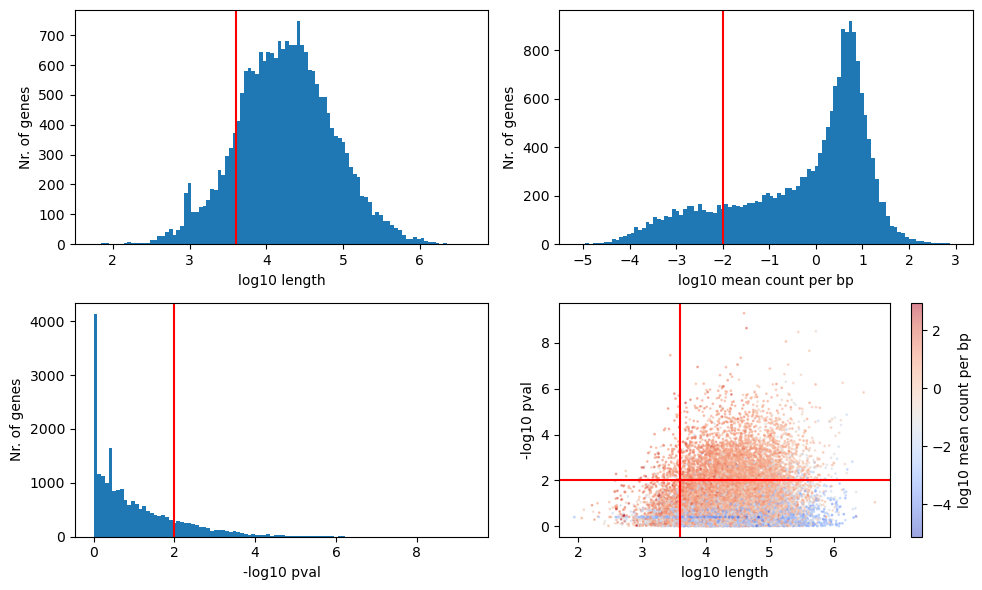

In [22]:
genome = 'GRCm38'
bin_size = 100 # bin size
n_bins_flank = 100

T = np.arange(0,48,4) # time points [h]
τ = 24 # period [h]
ω = 2*np.pi/τ # angular frequency [rad/h]
m = len(T) # number of time points
dx = bin_size # distance between positions [bp]

file_gene_phase = f'../results/{genome}/phase_amp/gene_phase_amp.csv'
gene_phase_amp = pd.read_csv(file_gene_phase,index_col=-1,sep='\t')
gene_phase_amp['length'] = gene_phase_amp['end'] - gene_phase_amp['start']
# get log 10 of length, mean count per bp, and pval
gene_phase_amp['length'] = np.log10(gene_phase_amp['length'])
gene_phase_amp['mean_count_per_bp'] = np.log10(gene_phase_amp['mean_count_per_bp'])
gene_phase_amp['pval'] = -np.log10(gene_phase_amp['pval'])
# and rename columns
gene_phase_amp.rename(columns={'length':'log10_length','mean_count_per_bp':'log10_mean_count_per_bp','pval':'-log10_pval'},inplace=True)

# Thresholds
th = {}
th['log10_length'] = 3.6
th['log10_mean_count_per_bp'] = -2
th['-log10_pval'] = 2

fig = plot_gene_phase_amp(gene_phase_amp, th)

idx_top = np.ones(gene_phase_amp.shape[0],dtype=bool)
for i in th:
    print(i)
    idx_top = idx_top & (gene_phase_amp[i].values > th[i])
    

#idx_top = (gene_phase_amp['R2'] > th['R2']) & (gene_phase_amp['length'] > th['length']) & (gene_phase_amp['mean_count_per_bp'] > th['mean_count_per_bp']) & (gene_phase_amp['pval'] > th['pval'])

idx_top = np.where(idx_top)[0]

print(len(idx_top))
# get genes relative expression along its body


In [31]:

Flank_rel_expression = {}
Flank_rel_phase = {}
Flank_amp = {}
Flank_R2 = {}
for strand in ['same','opp']:
    for pos in ['up','start','end','down']:
        flank = f'{strand}_{pos}'
        Flank_rel_expression[flank] = np.zeros((len(idx_top),n_bins_flank))*np.nan
        Flank_rel_phase[flank] = np.zeros((len(idx_top),n_bins_flank))*np.nan
        Flank_amp[flank] = np.zeros((len(idx_top),n_bins_flank))*np.nan
        Flank_R2[flank] = np.zeros((len(idx_top),n_bins_flank))*np.nan

#idx_top = idx_top[:24]

COORD = [gene_phase_amp.loc[gene_phase_amp.index[i],['chr','start','end','strand']].values for i in idx_top]
with Pool(92) as p:
    OUT = p.map(partial(get_flank_expression_phase, genome, bin_size, n_bins_flank),COORD)

for g,gene in enumerate(gene_phase_amp.iloc[idx_top].index):
    for flank in Flank_rel_expression:
        Flank_rel_expression[flank][g,:] = OUT[g][0][flank]
        Flank_rel_phase[flank][g,:] = OUT[g][1][flank]
        #Flank_amp[flank][g,:] = OUT[g][2][flank]
        #Flank_R2[flank][g,:] = OUT[g][3][flank]


/tmp/ipykernel_201099/551811909.py:102: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.fillna(0,inplace=True)
/tmp/ipykernel_201099/551811909.py:102: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.fillna(0,inplace=True)
/tmp/ipykernel_201099/551811909.py:102: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.fillna(0,inplace=True)
/tmp

/tmp/ipykernel_201099/2700963562.py:62: RuntimeWarning: Mean of empty slice
  mu = np.nanmean( Flank_rel_phase[flank]*w,0)/np.nanmean(w,0)
/tmp/ipykernel_201099/2700963562.py:62: RuntimeWarning: Mean of empty slice
  mu = np.nanmean( Flank_rel_phase[flank]*w,0)/np.nanmean(w,0)
/tmp/ipykernel_201099/2700963562.py:62: RuntimeWarning: Mean of empty slice
  mu = np.nanmean( Flank_rel_phase[flank]*w,0)/np.nanmean(w,0)
/tmp/ipykernel_201099/2700963562.py:62: RuntimeWarning: Mean of empty slice
  mu = np.nanmean( Flank_rel_phase[flank]*w,0)/np.nanmean(w,0)
/tmp/ipykernel_201099/2700963562.py:62: RuntimeWarning: Mean of empty slice
  mu = np.nanmean( Flank_rel_phase[flank]*w,0)/np.nanmean(w,0)
/tmp/ipykernel_201099/2700963562.py:62: RuntimeWarning: Mean of empty slice
  mu = np.nanmean( Flank_rel_phase[flank]*w,0)/np.nanmean(w,0)
/tmp/ipykernel_201099/2700963562.py:62: RuntimeWarning: Mean of empty slice
  mu = np.nanmean( Flank_rel_phase[flank]*w,0)/np.nanmean(w,0)
/tmp/ipykernel_201099/27009

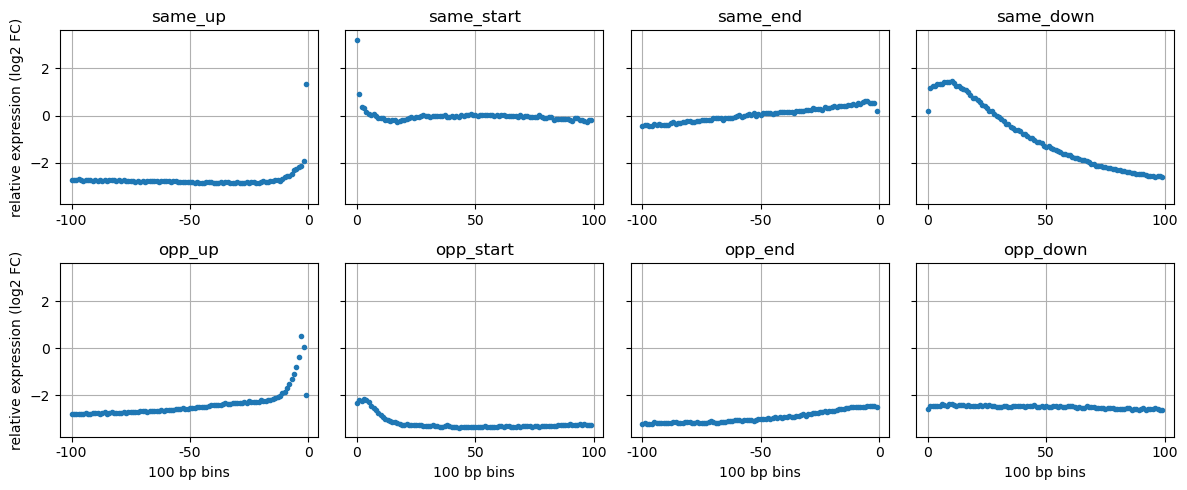

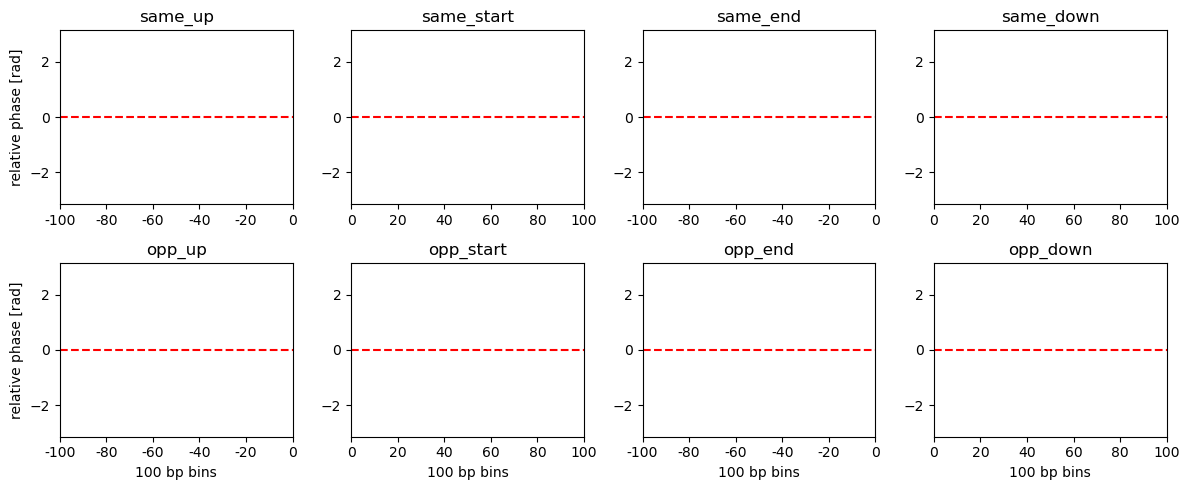

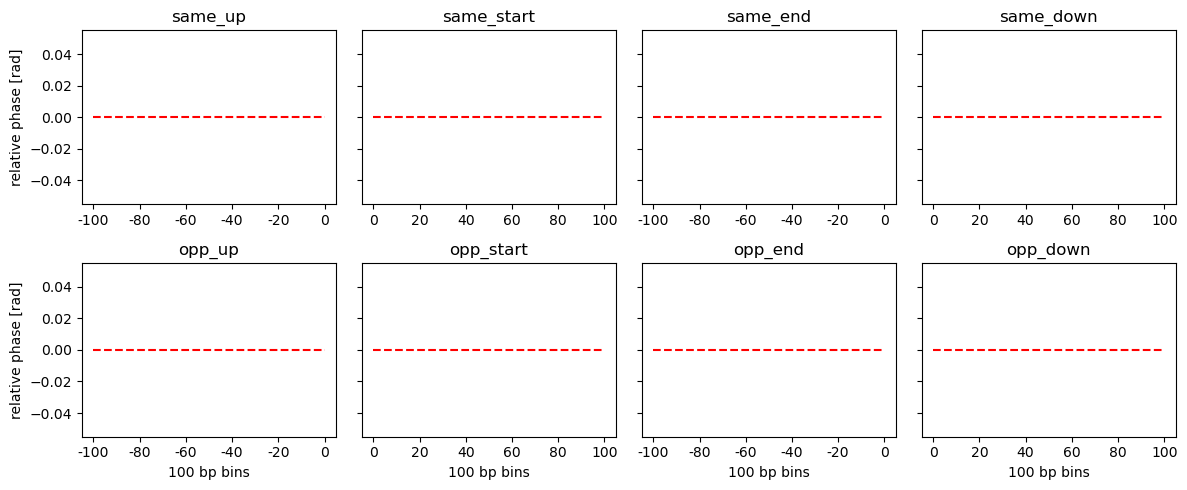

In [32]:
# plot phase and amplitude of flanks
fig, axes = plt.subplots(2, 4, figsize=(12, 5),sharey=True)
axes = axes.flatten()
for i, flank in enumerate(Flank_rel_expression):
    ax = axes[i]
    ax.errorbar(x=range(n_bins_flank),y=Flank_rel_expression[flank].mean(0),yerr=Flank_rel_expression[flank].std(0)/np.sqrt(len(idx_top)),fmt='.')
    ax.set_title(flank)
    if flank.split('_')[0] == 'opp':
        ax.set_xlabel(f'{bin_size} bp bins')
    # if up put xtick from -bins to 0
    if flank.split('_')[1]  in ['up','end']:
        ax.set_xticks(range(0,n_bins_flank+1,50),range(-n_bins_flank,1,50))
    else:
        ax.set_xticks(range(0,n_bins_flank+1,50),range(0,n_bins_flank+1,50))
    if flank.split('_')[1] == 'up':
        ax.set_ylabel('relative expression (log2 FC)')
    ax.grid()
    
fig.tight_layout()
fig.savefig('fig/Flank_expression_phase/Flank_expression.pdf',bbox_inches='tight')

fig, axes = plt.subplots(2, 4, figsize=(12, 5))
axes = axes.flatten()
for i, flank in enumerate(Flank_rel_phase):
    ax = axes[i]
    bins = np.linspace(-np.pi,np.pi,51)

    H = np.zeros((len(bins)-1,n_bins_flank))
    for b in range(n_bins_flank):
        H[:,b] = np.histogram(Flank_rel_phase[flank][:,b],bins=bins,weights=Flank_amp[flank][:,b]*Flank_R2[flank][:,b])[0]

    H /= H.sum(0,keepdims=True)

    bins_center = (bins[:-1] + bins[1:])/2
    mu = np.sum(bins_center[:,None] * H,0)

    #H = np.log2(H)
    ax.imshow(H,aspect='auto',interpolation='none',extent=[0,n_bins_flank,bins[0],bins[-1]],cmap='Blues',origin='lower')
    ax.plot([0,n_bins_flank],[0,0],'r--')
    #ax.scatter(range(n_bins_flank),mu,marker='.',color='g')
    ax.set_title(flank)
    if flank.split('_')[0] == 'opp':
        ax.set_xlabel(f'{bin_size} bp bins')
    # if up put xtick from -bins to 0
    if flank.split('_')[1] in ['up','end']:
        ax.set_xticks(range(0,n_bins_flank+1,20),range(-n_bins_flank,1,20))
    else:
        ax.set_xticks(range(0,n_bins_flank+1,20),range(0,n_bins_flank+1,20))
    if flank.split('_')[1] == 'up':
        ax.set_ylabel('relative phase [rad]')

fig.tight_layout()
fig.savefig('fig/Flank_expression_phase/Flank_phase.pdf',bbox_inches='tight')


fig, axes = plt.subplots(2, 4, figsize=(12, 5),sharey=True)
axes = axes.flatten()
for i, flank in enumerate(Flank_rel_phase):
    ax = axes[i]

    w = Flank_amp[flank]*Flank_R2[flank]
    mu = np.nanmean( Flank_rel_phase[flank]*w,0)/np.nanmean(w,0)
    std = np.nanstd( Flank_rel_phase[flank],0)/np.sqrt(np.sum( ~np.isnan(Flank_rel_phase[flank]), 0 ))

    #H = np.log2(H)
    ax.errorbar(range(n_bins_flank),mu,std,fmt='.')
    ax.plot([0,n_bins_flank],[0,0],'r--')
    ax.set_title(flank)
    if flank.split('_')[0] == 'opp':
        ax.set_xlabel(f'{bin_size} bp bins')
    # if up put xtick from -bins to 0
    if flank.split('_')[1] in ['up','end']:

        ax.set_xticks(range(0,n_bins_flank+1,20),range(-n_bins_flank,1,20))
    else:
        ax.set_xticks(range(0,n_bins_flank+1,20),range(0,n_bins_flank+1,20))
    if flank.split('_')[1] == 'up':
        ax.set_ylabel('relative phase [rad]')

fig.tight_layout()
fig.savefig('fig/Flank_expression_phase/Flank_phase_mean_std.pdf',bbox_inches='tight')

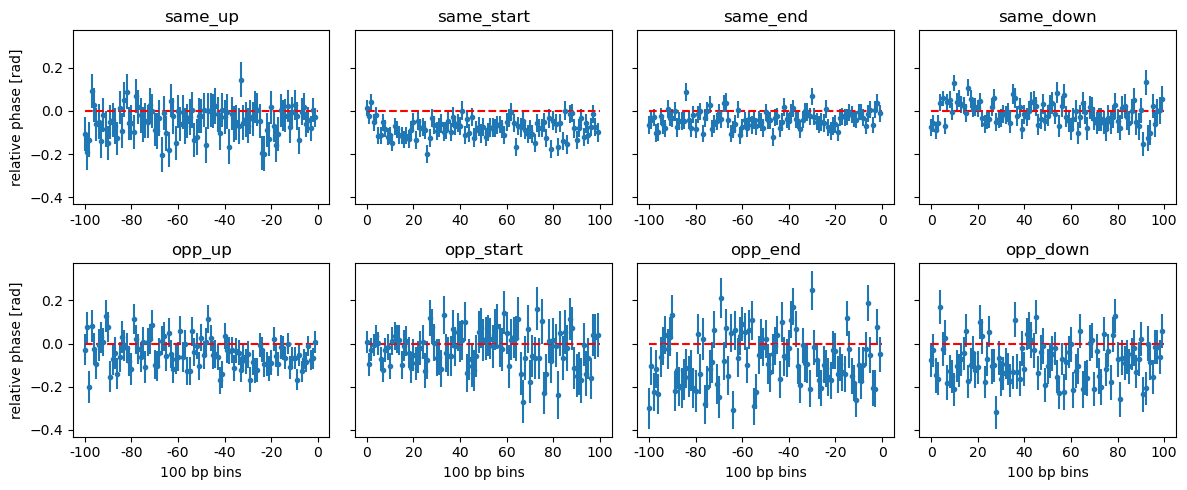

In [5]:
fig, axes = plt.subplots(2, 4, figsize=(12, 5),sharey=True)
axes = axes.flatten()
for i, flank in enumerate(Flank_rel_phase):
    ax = axes[i]

    mu = np.nanmean( Flank_rel_phase[flank],0)
    std = np.nanstd( Flank_rel_phase[flank],0)/np.sqrt(np.sum( ~np.isnan(Flank_rel_phase[flank]), 0 ))

    #H = np.log2(H)
    ax.errorbar(range(n_bins_flank),mu,std,fmt='.')
    ax.plot([0,n_bins_flank],[0,0],'r--')
    ax.set_title(flank)
    if flank.split('_')[0] == 'opp':
        ax.set_xlabel(f'{bin_size} bp bins')
    # if up put xtick from -bins to 0
    if flank.split('_')[1] in ['up','end']:

        ax.set_xticks(range(0,n_bins_flank+1,20),range(-n_bins_flank,1,20))
    else:
        ax.set_xticks(range(0,n_bins_flank+1,20),range(0,n_bins_flank+1,20))
    if flank.split('_')[1] == 'up':
        ax.set_ylabel('relative phase [rad]')

fig.tight_layout()
fig.savefig('fig/Flank_expression_phase/Flank_phase_mean_std.pdf',bbox_inches='tight')

In [28]:
Flank_amp[flank]*Flank_R2[flank]


array([[       nan,        nan,        nan, ..., 0.16563551, 0.09914465,
        0.22571198],
       [       nan,        nan,        nan, ...,        nan,        nan,
               nan],
       [       nan,        nan,        nan, ..., 0.14679605, 0.02788367,
        0.08608974],
       ...,
       [       nan,        nan,        nan, ...,        nan,        nan,
        0.0098565 ],
       [       nan,        nan,        nan, ..., 0.02028181, 0.45942911,
        0.39279775],
       [0.1454296 , 0.04238166, 0.72223258, ..., 1.34281286, 0.0627099 ,
        0.05378738]])

In [7]:
Flank_rel_phase[flank].shape

(1105, 100)

In [10]:
Flank_rel_phase[flank].shape

(1105, 100)